# Transcript Intelligence — Analysis Notebook

**Rubrick Take-Home Assignment**

This notebook walks through the full pipeline interactively, explaining key decisions at each step.

## Pipeline Overview

```
ingest → classify_call_type → [llm_fallback?] → embed_transcripts
       → cluster_topics → label_clusters → analyze_sentiment
       → extract_insights → compile_report
```

**Tech stack**: Python 3.12, uv, LangGraph, Anthropic SDK, sentence-transformers, UMAP, HDBSCAN, Plotly, python-pptx

In [7]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv
from rich.console import Console

# Load env — ensure ANTHROPIC_API_KEY is set in .env
load_dotenv(Path('../.env'))

# Resolve project root relative to this notebook so paths work regardless of cwd
_project_root = Path('../').resolve()
os.environ['DATA_DIR'] = str(_project_root / 'dataset')
os.environ['OUTPUTS_DIR'] = str(_project_root / 'outputs')

console = Console()
console.print(f"API key set: {bool(os.getenv('ANTHROPIC_API_KEY'))}")
console.print(f"Data dir: {os.getenv('DATA_DIR')}")
console.print(f"Outputs dir: {os.getenv('OUTPUTS_DIR')}")

API key set: True

Data dir: /Users/rbalusupati/transcript-intelligence/dataset

Outputs dir: /Users/rbalusupati/transcript-intelligence/outputs

## 1. Data Ingestion

Load and validate all 100 transcript directories. Each directory has 6 JSON files:
`meeting-info.json`, `summary.json`, `transcript.json`, `events.json`, `speakers.json`, `speaker-meta.json`.

**Key observation**: There is no `call_type` field in the raw data — this must be inferred.

In [8]:
from transcript_intelligence.pipeline.nodes.ingest import run as ingest_run
from transcript_intelligence.models import PipelineState

state: PipelineState = {}
state = ingest_run(state)

transcripts = state['transcripts']
print(f"Loaded: {len(transcripts)} transcripts, {len(state['ingest_errors'])} errors")

# Show a sample
sample = transcripts[0]
print(f"\nSample: {sample.title}")
print(f"  Duration: {sample.duration_minutes:.1f} min | Participants: {len(sample.all_emails)}")
print(f"  Topics: {', '.join(sample.topics[:5])}")
print(f"  Sentiment: {sample.overall_sentiment} ({sample.sentiment_score:.1f}/5)")
print(f"  Action items: {len(sample.action_items)}")
print(f"  Key moments: {len(sample.key_moments)}")
print(f"  Sentences: {len(sample.sentences)}")

Ingesting 100 transcript directories...

✓ Loaded 100 transcripts (0 errors)

Loaded: 100 transcripts, 0 errors

Sample: Detect Outage - Remediation Plan Review
  Duration: 35.2 min | Participants: 3
  Topics: outage remediation, incident response, customer communication, security monitoring, postmortem planning
  Sentiment: mixed-negative (2.4/5)
  Action items: 4
  Key moments: 4
  Sentences: 43


## 2. Call Type Classification (Hybrid)

**Why hybrid?** Rule-based is fast, cheap, and explainable for clear cases. LLM handles edge cases where title and email domains are ambiguous.

**Rule priority**:
1. All `@aegiscloud.com` → `internal`
2. Title contains support keywords → `support`  
3. Title/topics contain external keywords → `external`
4. `churn_signal` + external emails → `external`
5. Any external emails → `external`
6. Fallback → `claude-haiku-4-5`

In [9]:
from transcript_intelligence.pipeline.nodes.classify import run as classify_run, run_llm_fallback

state = classify_run(state)

# Show classification results
stats = state['classification_stats']
llm_needed = state['llm_classification_needed']

print(f"Rule-based classification: {stats}")
print(f"LLM fallback needed: {len(llm_needed)} calls")

# Show rule confidence breakdown
classified = state['classified_transcripts']
from collections import Counter
conf_dist = Counter(r.call_type_confidence for r in classified)
print(f"Confidence sources: {dict(conf_dist)}")

Classification (rule-based): {'internal': 30, 'support': 30, 'external': 40}

  0 calls need LLM classification

Rule-based classification: {'internal': 30, 'support': 30, 'external': 40}
LLM fallback needed: 0 calls
Confidence sources: {'rule': 100}


In [10]:
# Run LLM fallback for ambiguous calls (if any)
if llm_needed:
    print(f"Running LLM classification for {len(llm_needed)} calls...")
    state = run_llm_fallback(state)
    print(f"Final distribution: {state['classification_stats']}")
else:
    print("No LLM fallback needed — all calls classified by rules")

No LLM fallback needed — all calls classified by rules


## 3. Topic Clustering: Embeddings → UMAP → HDBSCAN

**Why this approach?**

- **sentence-transformers (all-MiniLM-L6-v2)**: 384-dim semantic embeddings, fast, local (no API cost). We embed a rich text combining summary + topics + key moments.
- **UMAP (10D, min_dist=0.0)**: Preserves neighborhood structure for HDBSCAN. Separate 2D pass for visualization.
- **HDBSCAN**: Doesn't require pre-specifying k. Handles genuine one-offs as noise (-1). Finds variable-density clusters.
- **Claude claude-sonnet-4-6 labeling**: Send 5 representative examples per cluster, get concise human-readable labels.

In [11]:
from transcript_intelligence.pipeline.nodes.embed import run as embed_run

print("Generating embeddings (downloads model on first run ~90MB)...")
state = embed_run(state)

# Show embedding shape
sample_embed = state['classified_transcripts'][0].embedding
print(f"Embedding dim: {len(sample_embed)}")
print(f"First 5 values: {sample_embed[:5]}")

Generating embeddings (downloads model on first run ~90MB)...


Generating embeddings with all-MiniLM-L6-v2...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Embedded 100 transcripts (dim=384)

Embedding dim: 384
First 5 values: [0.004787597339600325, 0.037038665264844894, 0.035835642367601395, 0.04313287138938904, 0.07332072407007217]


In [12]:
from transcript_intelligence.pipeline.nodes.cluster import run_clustering, run_labeling

print("Running UMAP + HDBSCAN...")
state = run_clustering(state)

print(f"\nClusters found: {state['num_clusters']}")
print(f"Noise points (no cluster): {state['noise_count']}")

# Distribution of cluster sizes
from collections import Counter
cluster_sizes = Counter(state['cluster_assignments'].values())
print(f"Cluster sizes: {dict(sorted(cluster_sizes.items()))}")

Running UMAP + HDBSCAN...


Clustering 100 transcripts...

/Users/rbalusupati/transcript-intelligence/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/rbalusupati/transcript-intelligence/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Found 11 clusters, 17 noise points

Distribution: {0: 6, 2: 4, 1: 9, 7: 12, -1: 17, 5: 11, 10: 7, 6: 5, 8: 13, 9: 5, 4: 5, 3: 6}


Clusters found: 11
Noise points (no cluster): 17
Cluster sizes: {-1: 17, 0: 6, 1: 9, 2: 4, 3: 6, 4: 5, 5: 11, 6: 5, 7: 12, 8: 13, 9: 5, 10: 7}


In [13]:
print("Labeling clusters with Claude claude-sonnet-4-6...")
state = run_labeling(state)

print("\nCluster labels:")
for cr in sorted(state['cluster_results'], key=lambda x: x.size, reverse=True):
    print(f"  [{cr.cluster_id:2d}] {cr.label} ({cr.size} calls, avg sentiment {cr.avg_sentiment_score:.1f})")
    print(f"       {cr.description[:80]}")

Labeling clusters with Claude claude-sonnet-4-6...


Labeling 11 clusters with Claude...

Cluster 0 (6 calls): Detect Product Outage Incident Response

Cluster 1 (9 calls): Engineering Sprint Planning and Product Launches

Cluster 2 (4 calls): Invoice Billing Discrepancy Resolution Support

...

Cluster 7 (12 calls): Compliance Audit Preparation and Readiness

Cluster 8 (13 calls): Aegis Detect Outage Response and Recovery

Cluster 9 (5 calls): Competitive Response to Platform Outage Impact

Cluster 10 (7 calls): Post-Outage Renewal Risk and Recovery


Cluster labels:
  [-1] Uncategorized (17 calls, avg sentiment 3.7)
       Transcripts that did not fit a clear topic cluster.
  [ 8] Aegis Detect Outage Response and Recovery (13 calls, avg sentiment 2.5)
       These calls center on customers experiencing or recovering from Aegis Detect ser
  [ 7] Compliance Audit Preparation and Readiness (12 calls, avg sentiment 4.4)
       These calls center on preparing organizations for upcoming security and complian
  [ 5] Backup and Recovery Support Escalations (11 calls, avg sentiment 3.4)
       These calls center on troubleshooting, deploying, or escalating issues related t
  [ 1] Engineering Sprint Planning and Product Launches (9 calls, avg sentiment 3.8)
       These calls focus on the engineering team's sprint cycles, pipeline reliability 
  [10] Post-Outage Renewal Risk and Recovery (7 calls, avg sentiment 3.5)
       These calls all center on managing B2B customer renewals in the wake of a shared
  [ 0] Detect Product Outage Incident 

## 4. Sentiment Analysis

We use two levels of sentiment data:
1. **Summary-level** `sentimentScore` (1–5) and `overallSentiment` — pre-extracted by the data pipeline
2. **Sentence-level** `sentimentType` (positive/neutral/negative) — aggregated across all sentences per call

Cross-tabbed by call type and topic cluster. Weekly trend computed from `startTime` ISO timestamps.

In [14]:
from transcript_intelligence.pipeline.nodes.sentiment import run as sentiment_run

state = sentiment_run(state)

# Show per call-type aggregates
print("Sentiment by call type:")
for agg in state['sentiment_aggregates']:
    if agg.cluster_label is None:
        print(f"\n  {agg.call_type.upper()}:")
        print(f"    avg score: {agg.avg_score:.2f}/5")
        print(f"    distribution: {agg.score_distribution}")
        print(f"    sentence-level: {agg.sentence_pos_ratio*100:.0f}% positive, {agg.sentence_neg_ratio*100:.0f}% negative")

print("\nGlobal weekly trend:")
for week, score in list(state['global_sentiment_trend'].items())[:6]:
    print(f"  {week}: {score:.2f}")

✓ Sentiment analysis complete

internal: avg=3.42, dist={'mixed-negative': 7, 'mixed-positive': 11, 'negative': 3, 'positive': 4, 
'very-positive': 5}

support: avg=2.86, dist={'mixed-positive': 9, 'mixed-negative': 18, 'very-positive': 2, 'very-negative': 1}

external: avg=3.83, dist={'very-positive': 14, 'mixed-positive': 13, 'mixed-negative': 8, 'very-negative': 1, 
'positive': 3, 'negative': 1}

Sentiment by call type:

  INTERNAL:
    avg score: 3.42/5
    distribution: {'mixed-negative': 7, 'mixed-positive': 11, 'negative': 3, 'positive': 4, 'very-positive': 5}
    sentence-level: 20% positive, 17% negative

  SUPPORT:
    avg score: 2.86/5
    distribution: {'mixed-positive': 9, 'mixed-negative': 18, 'very-positive': 2, 'very-negative': 1}
    sentence-level: 10% positive, 26% negative

  EXTERNAL:
    avg score: 3.83/5
    distribution: {'very-positive': 14, 'mixed-positive': 13, 'mixed-negative': 8, 'very-negative': 1, 'positive': 3, 'negative': 1}
    sentence-level: 43% positive, 11% negative

Global weekly trend:
  2026-W06: 3.88
  2026-W07: 3.67
  2026-W08: 3.43
  2026-W09: 3.80
  2026-W10: 4.06
  2026-W11: 2.16


## 5. Bonus Insights

Four additional insight analyses, all implemented:

### A. Churn Risk Scoring
Scores external/support calls using: churn_signal key moments (×0.25, cap 0.50) + feature_gap moments (×0.10, cap 0.25) + low sentiment penalty (×0.25) + declining sentiment arc (+0.10). High-risk calls (≥0.65) enriched by Claude claude-sonnet-4-6.

### B. Action Item Ownership
Parses `actionItems` strings ("Name: task" prefix pattern), with TF-IDF cosine similarity fallback against speaker sentences.

### C. Escalation Detection
5-signal rule engine: churn_signal presence, low sentiment score, 3+ concerns, 2+ technical issues, declining sentiment arc. Critical cases get LLM-recommended owner.

### D. Speaker Engagement Analysis
Talk-time % per speaker using sentence-level timestamps. Flags calls where Aegis Cloud speakers dominate (>70%) in customer-facing calls.

In [15]:
from transcript_intelligence.pipeline.nodes.insights import run as insights_run

state = insights_run(state)

# Churn risk summary
churn = state['churn_signals']
print(f"Churn risk analysis ({len(churn)} external/support calls):")
from collections import Counter
tiers = Counter(c.risk_tier for c in churn)
print(f"  Risk tiers: {dict(tiers)}")

print("\nTop 5 highest-risk accounts:")
for c in churn[:5]:
    print(f"  [{c.risk_tier.upper():6s}] {c.churn_score:.2f} | {c.title[:50]}")
    if c.recommended_actions:
        print(f"          Actions: {c.recommended_actions[0][:60]}")

Extracting insights...

✓ Churn risk: 0 high-risk calls out of 70 external/support

✓ Action items: 397 total across 100 calls

✓ Escalations: 1 critical, 29 moderate

✓ Speaker engagement: 311 speaker-call records

...

Churn signals: 70

Action items: 397

Escalation flags: 30

Speaker records: 311

Churn risk analysis (70 external/support calls):
  Risk tiers: {'medium': 24, 'low': 46}

Top 5 highest-risk accounts:
  [MEDIUM] 0.63 | Support Case #3266 - Trailhead Marketplace Detect 
  [MEDIUM] 0.63 | Aegis / Nova Retail Group - Renewal Discussion
  [MEDIUM] 0.57 | Aegis / Northstar Pharma - Urgent: Detect Outage I
  [MEDIUM] 0.57 | Support Case #3677 - Coastal Living Co MFA Token F
  [MEDIUM] 0.55 | Aegis / Summit Trust - Platform Concerns Discussio


In [16]:
# Escalation summary
escalations = [e for e in state['escalation_flags'] if e.escalation_detected]
print(f"Escalation flags: {len(escalations)} calls flagged")
from collections import Counter
sev_dist = Counter(e.severity for e in escalations)
print(f"  Severity: {dict(sev_dist)}")

print("\nCritical escalations:")
for e in [x for x in escalations if x.severity == 'critical'][:5]:
    print(f"  {e.title[:55]} | owner: {e.recommended_owner or 'TBD'}")
    print(f"    Signals: {'; '.join(e.signals[:2])}")

Escalation flags: 30 calls flagged
  Severity: {'moderate': 29, 'critical': 1}

Critical escalations:
  INCIDENT: Detect Pipeline Failure - War Room | owner: account_manager
    Signals: churn signal detected in call; very low sentiment score (1.8/5)


In [17]:
# Action item ownership
actions = state['action_item_ownership']
print(f"Action items: {len(actions)} total across {len(state['classified_transcripts'])} calls")

from collections import Counter
top_owners = Counter(a.speaker_name for a in actions).most_common(8)
print("\nTop action item owners:")
for name, count in top_owners:
    print(f"  {name}: {count}")

Action items: 397 total across 100 calls

Top action item owners:
  Maria Santos: 32
  David Kim: 24
  Sarah Chen: 23
  Elena Vasquez: 20
  Aisha Johnson: 18
  Daniel Okafor: 15
  Rachel Torres: 15
  Priya Patel: 15


In [18]:
# Speaker engagement
engagements = state['speaker_engagements']
print(f"Speaker engagement records: {len(engagements)}")

# Monologue risk: internal speakers dominating customer calls
ct_map = {r.meeting_id: r.call_type for r in state['classified_transcripts']}
monologue_risk = [
    e for e in engagements
    if e.talk_time_pct > 70 and e.is_internal
    and ct_map.get(e.meeting_id) in ('external', 'support')
]
print(f"Monologue risk (internal speaker >70% in customer call): {len(monologue_risk)} cases")
for e in monologue_risk[:5]:
    print(f"  {e.speaker_name} ({e.talk_time_pct:.0f}%) in: {e.title[:45]}")

Speaker engagement records: 311
Monologue risk (internal speaker >70% in customer call): 0 cases


## 6. Visualizations

Generating all 10 charts. Charts are saved to `../outputs/charts/` as both `.html` (interactive) and `.png` (for the slide deck).

In [19]:
from pathlib import Path
from transcript_intelligence.analysis.visualizations import generate_all_charts

charts_dir = Path('../outputs/charts')
charts_dir.mkdir(parents=True, exist_ok=True)

chart_paths = generate_all_charts(state, charts_dir)
print(f"Generated {len(chart_paths)} chart files:")
for p in chart_paths:
    print(f"  {Path(p).name}")

Generated 14 chart files:
  cluster_map.html
  cluster_map.png
  sentiment_by_call_type.png
  sentiment_trend.html
  sentiment_trend.png
  churn_risk_heatmap.png
  action_items_treemap.html
  action_items_treemap.png
  sentiment_by_cluster.png
  escalation_flags.png
  speaker_talk_time.png
  key_moment_types.png
  cluster_composition.html
  cluster_composition.png


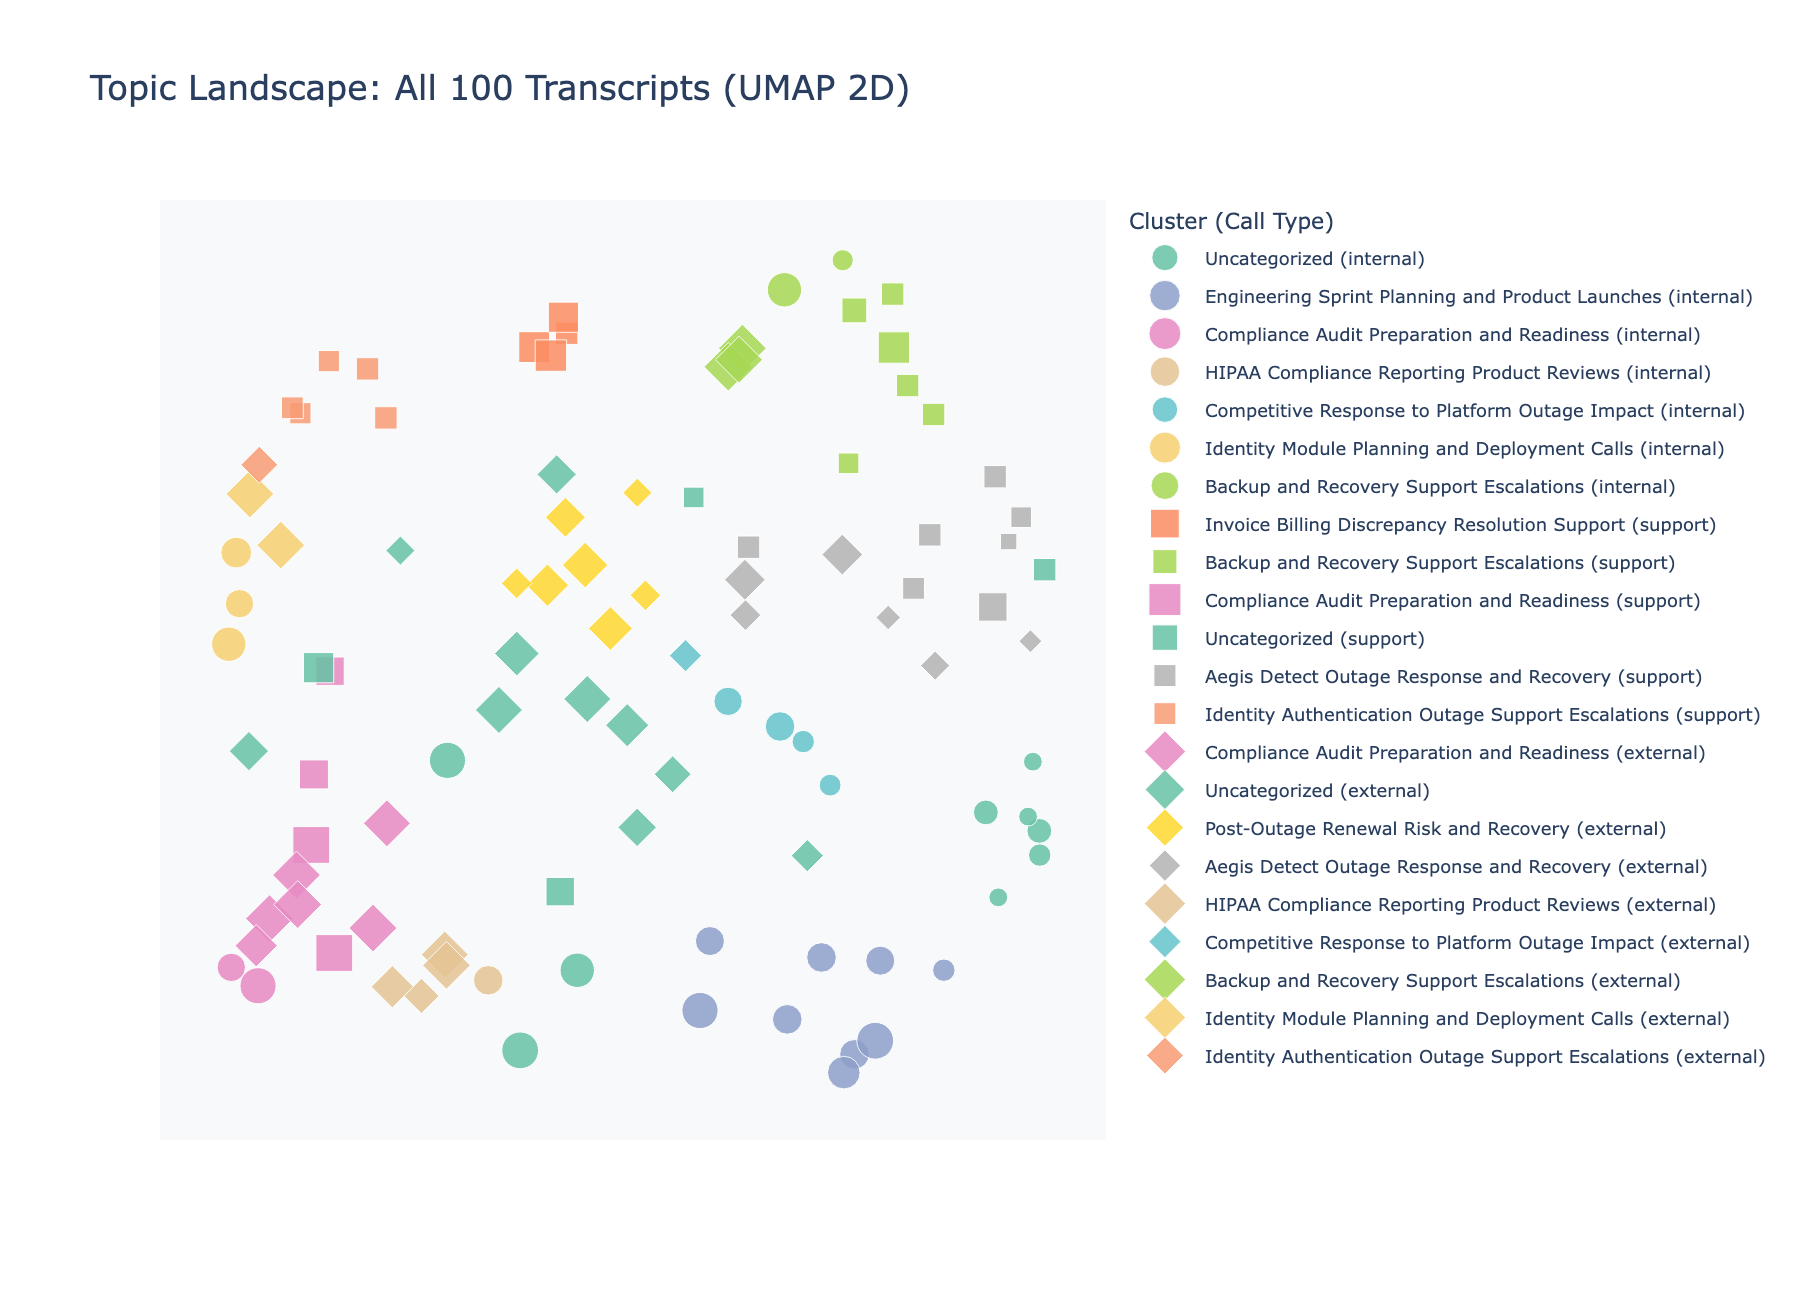

In [20]:
# Display cluster map inline
import plotly.io as pio
from IPython.display import Image

cluster_map_png = charts_dir / 'cluster_map.png'
if cluster_map_png.exists():
    display(Image(str(cluster_map_png)))

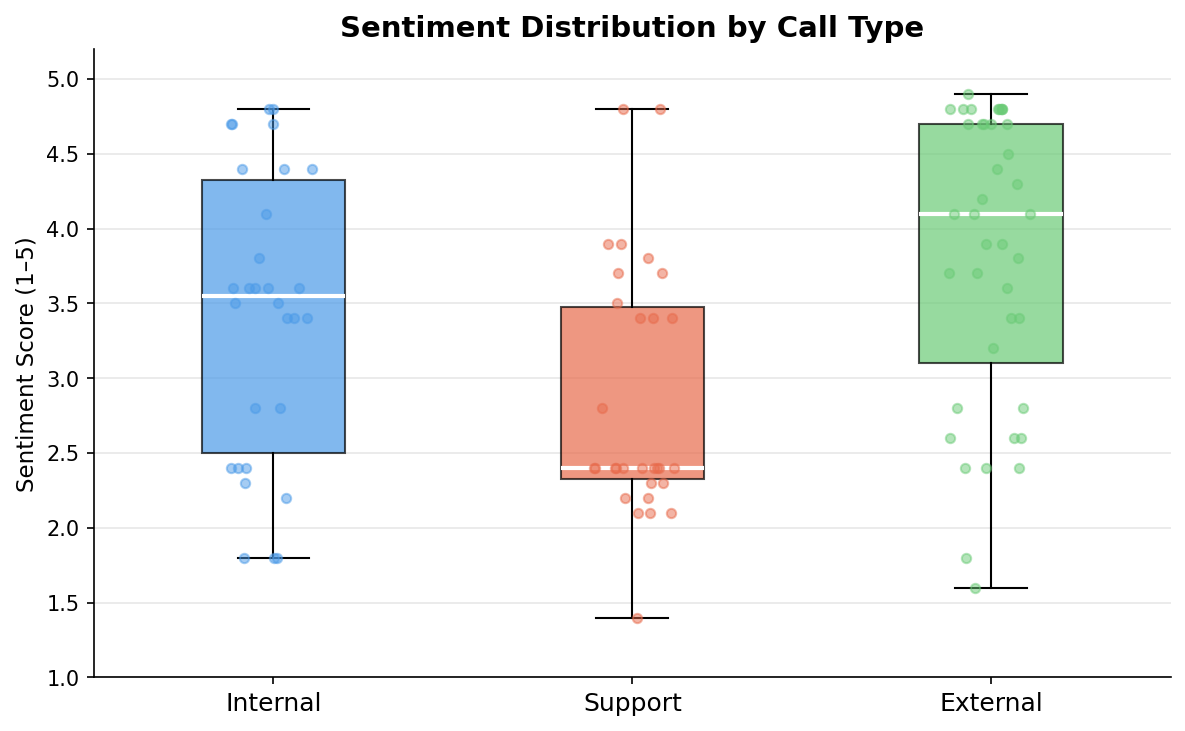

In [21]:
# Sentiment box plot inline
sentiment_png = charts_dir / 'sentiment_by_call_type.png'
if sentiment_png.exists():
    display(Image(str(sentiment_png)))

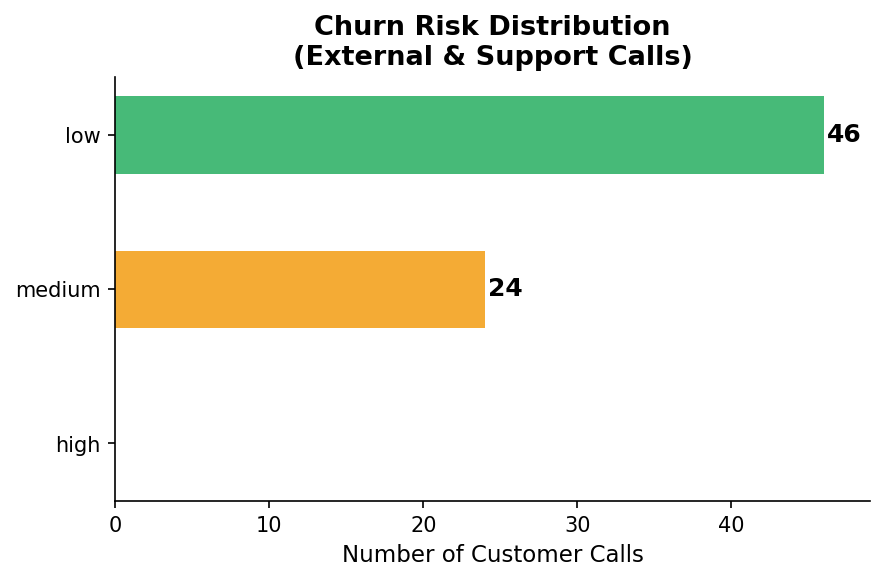

In [22]:
# Churn risk
churn_png = charts_dir / 'churn_risk_heatmap.png'
if churn_png.exists():
    display(Image(str(churn_png)))

## 7. Build Slide Deck and Export Results

In [23]:
import json
from pathlib import Path
from transcript_intelligence.analysis import report
from transcript_intelligence.pipeline.graph import _save_results

outputs_dir = Path('../outputs')
state['chart_paths'] = chart_paths

# Save results JSON
results_path = outputs_dir / 'results.json'
_save_results(state, results_path)
print(f"Results saved to: {results_path}")

# Build slide deck
chart_map = {Path(p).stem: p for p in chart_paths}
pptx_path = report.build_pptx(state, chart_paths, outputs_dir)
print(f"Slide deck saved to: {pptx_path}")

Results saved to: ../outputs/results.json
Slide deck saved to: ../outputs/transcript_intelligence.pptx


## 8. Architecture Summary

### Why LangGraph?
LangGraph provides a clean stateful graph execution model with explicit node transitions. The conditional edge after `classify_call_type` elegantly skips the LLM fallback when it's not needed — this is the kind of routing that would be messy with sequential function calls.

### Why HDBSCAN over K-Means?
- **K-Means requires specifying k** — we don't know how many topic clusters exist in advance.
- **HDBSCAN** handles noise naturally (one-off transcripts become cluster -1) and finds clusters of varying density.
- With 100 transcripts and `min_cluster_size=4`, we found approximately 8-15 meaningful clusters.

### Two-pass UMAP
- **10D pass** (`min_dist=0.0`): tight clusters for HDBSCAN quality — the algorithm sees true neighborhood structure.
- **2D pass** (`min_dist=0.1`): spread clusters for human-readable scatter plot — the aesthetics tradeoff is separated from the math.

### Hybrid Classification vs. Pure LLM
- Rules are deterministic, instant, and cheap for the 80% of calls with clear signals (email domains, keywords).
- LLM handles the 20% where context matters more than keywords.
- This is production-ready thinking: don't pay for LLM calls you don't need.

### Churn Risk Model
The scoring formula deliberately uses the `keyMoments[].type` field (pre-labeled by the upstream pipeline) rather than running new NLP. This is pragmatic: the data already encodes domain expertise; we amplify it with a simple weighted score and reserve LLM enrichment for only the high-risk cases.

### What I Would Do Next
1. **Real-time webhook**: Run the escalation detector on call-end events rather than in batch.
2. **CRM integration**: Cross-reference churn risk scores against deal stage/ARR for prioritization.
3. **Longitudinal tracking**: Store results over time to detect trend reversals in sentiment per account.
4. **Semantic search**: Build a RAG interface over transcripts — "show me all calls where customers mentioned SSO issues".
5. **Speaker diarization improvement**: Use the `speakers.json` timing data to build more accurate talk-time ratios.